# Deep CFR: Architecture And Advantage-Fitting Budget

This experiment compares three advantage/strategy-network architectures and two fixed advantage-fitting budgets under equal measured training time. All runs use positive-regret-weighted MSE with `beta=0.5`.

The primary metric is **exact generated-average exploitability versus training seconds**. This captures the practical trade-off between network capacity, fitting quality, traversal speed, and the number of CFR iterations completed.

In [1]:
import gc
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'liars_poker').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from liars_poker.algo.deep_cfr import DeepCFRTrainer
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.core import GameSpec
from liars_poker.training.deep_cfr import deep_cfr_timed_loop

In [3]:
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=2,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)

training_seconds = 10 * 60
seed = 17
traversals_per_player = 50
eval_every = 10
positive_beta = 0.5

architectures = {
    '64x64': (64, 64),
    '128x128': (128, 128),
    '256x256': (256, 256),
    '64x128x64': (64, 128, 64),
}
advantage_step_options = (100, 300)

common_kwargs = {
    'advantage_buffer_capacity': 100_000,
    'strategy_buffer_capacity': 100_000,
    'batch_size': 128,
    'strategy_train_steps': 100,
    'learning_rate': 1e-3,
    'strategy_weighting': 'linear',
    'highest_regret_fallback': True,
    'alternating_updates': True,
    'retrain_advantage_from_scratch': False,
    'validation_fraction': 0.05,
    'validation_buffer_capacity': 10_000,
    'seed': seed,
}

spec.to_short_str(), training_seconds, architectures, advantage_step_options

('r4_s4_h2_hpt_ss',
 600,
 {'64x64': (64, 64),
  '128x128': (128, 128),
  '256x256': (256, 256),
  '64x128x64': (64, 128, 64)},
 (100, 300))

## Positive-weighted advantage loss

Positive sampled-regret targets receive action weight `1 + beta`; other legal targets receive action weight `1`. Strategy-network training remains unchanged.

In [4]:
class PositiveWeightedDeepCFRTrainer(DeepCFRTrainer):
    def __init__(self, spec, *, positive_beta=0.5, **kwargs):
        super().__init__(spec, **kwargs)
        self.positive_beta = float(positive_beta)

    def _train_model(self, model, optimizer, buffer, steps, *, strategy_loss):
        if strategy_loss:
            return super()._train_model(
                model,
                optimizer,
                buffer,
                steps,
                strategy_loss=True,
            )
        if buffer.size == 0 or steps <= 0:
            return 0.0

        model.train()
        total_loss = 0.0
        for _ in range(steps):
            features, targets, masks, weights = buffer.sample(self.batch_size, self.rng)
            x = torch.from_numpy(features).to(self.device)
            y = torch.from_numpy(targets).to(self.device)
            mask = torch.from_numpy(masks).to(self.device)
            sample_weight = torch.from_numpy(weights).to(self.device)
            sample_weight = sample_weight / sample_weight.mean().clamp_min(1e-8)

            pred = model(x)
            action_weight = mask.float() * (1.0 + self.positive_beta * (y > 0.0).float())
            per_sample = ((pred - y).square() * action_weight).sum(dim=1) / action_weight.sum(dim=1).clamp_min(1.0)
            loss = (per_sample * sample_weight).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())

        model.eval()
        return total_loss / steps

## Run six equal-time experiments

Runs use one shared seed for initial screening. Large trainers and buffers are released after each run; only logs and lightweight metadata are retained.

In [5]:
runs = []

for architecture_label, hidden_sizes in architectures.items():
    for advantage_steps in advantage_step_options:
        label = f'{architecture_label}; advantage steps={advantage_steps}'
        print(f'\n=== {label} ===')
        trainer = PositiveWeightedDeepCFRTrainer(
            spec,
            hidden_sizes=hidden_sizes,
            advantage_train_steps=advantage_steps,
            positive_beta=positive_beta,
            **common_kwargs,
        )
        parameter_count = sum(parameter.numel() for parameter in trainer.advantage_nets[0].parameters())
        exact_averager = ExactDenseStrategyAverager(spec)
        _, logs, trainer = deep_cfr_timed_loop(
            spec,
            training_seconds=training_seconds,
            trainer=trainer,
            traversals_per_player=traversals_per_player,
            eval_every=eval_every,
            exact_averager=exact_averager,
            debug=True,
        )
        runs.append({
            'label': label,
            'architecture': architecture_label,
            'hidden_sizes': hidden_sizes,
            'advantage_steps': advantage_steps,
            'parameters_per_network': parameter_count,
            'iterations': trainer.iteration,
            'logs': logs,
        })
        del trainer, exact_averager
        gc.collect()


=== 64x64; advantage steps=100 ===
[deep-cfr] iter=1 training_budget=1.95/600.00s traverse=0.47s fit=1.48s
[deep-cfr] iter=2 training_budget=4.96/600.00s traverse=1.63s fit=1.38s
[deep-cfr] iter=3 training_budget=7.37/600.00s traverse=1.12s fit=1.29s
[deep-cfr] iter=4 training_budget=9.72/600.00s traverse=1.05s fit=1.31s
[deep-cfr] iter=5 training_budget=12.21/600.00s traverse=1.25s fit=1.25s
[deep-cfr] iter=6 training_budget=14.46/600.00s traverse=1.00s fit=1.25s
[deep-cfr] iter=7 training_budget=17.00/600.00s traverse=1.20s fit=1.33s
[deep-cfr] iter=8 training_budget=19.38/600.00s traverse=1.18s fit=1.20s
[deep-cfr] iter=9 training_budget=21.85/600.00s traverse=1.21s fit=1.25s
[deep-cfr] iter=10 training_budget=24.36/600.00s traverse=1.26s fit=1.25s
[deep-cfr] iter=11 training_budget=26.74/600.00s traverse=1.16s fit=1.21s
[deep-cfr] iter=12 training_budget=29.17/600.00s traverse=1.24s fit=1.19s
[deep-cfr] iter=13 training_budget=31.53/600.00s traverse=1.12s fit=1.23s
[deep-cfr] iter

In [6]:
def evaluation_seconds(run):
    elapsed_by_iter = {
        record['iteration']: record['elapsed_s']
        for record in run['logs']['training_series']
    }
    return np.asarray([
        elapsed_by_iter[point['iter']]
        for point in run['logs']['exploitability_series']
    ])


def exploitability_values(run, key):
    return np.asarray([
        2 * point[key] - 1
        for point in run['logs']['exploitability_series']
    ])


def validation_series(run, family, key):
    records = [record for record in run['logs']['training_series'] if 'validation' in record]
    x = np.asarray([record['elapsed_s'] for record in records])
    y = np.asarray([
        np.mean([player[key] for player in record['validation'][family] if key in player])
        for record in records
    ])
    return x, y

## Results by measured training time

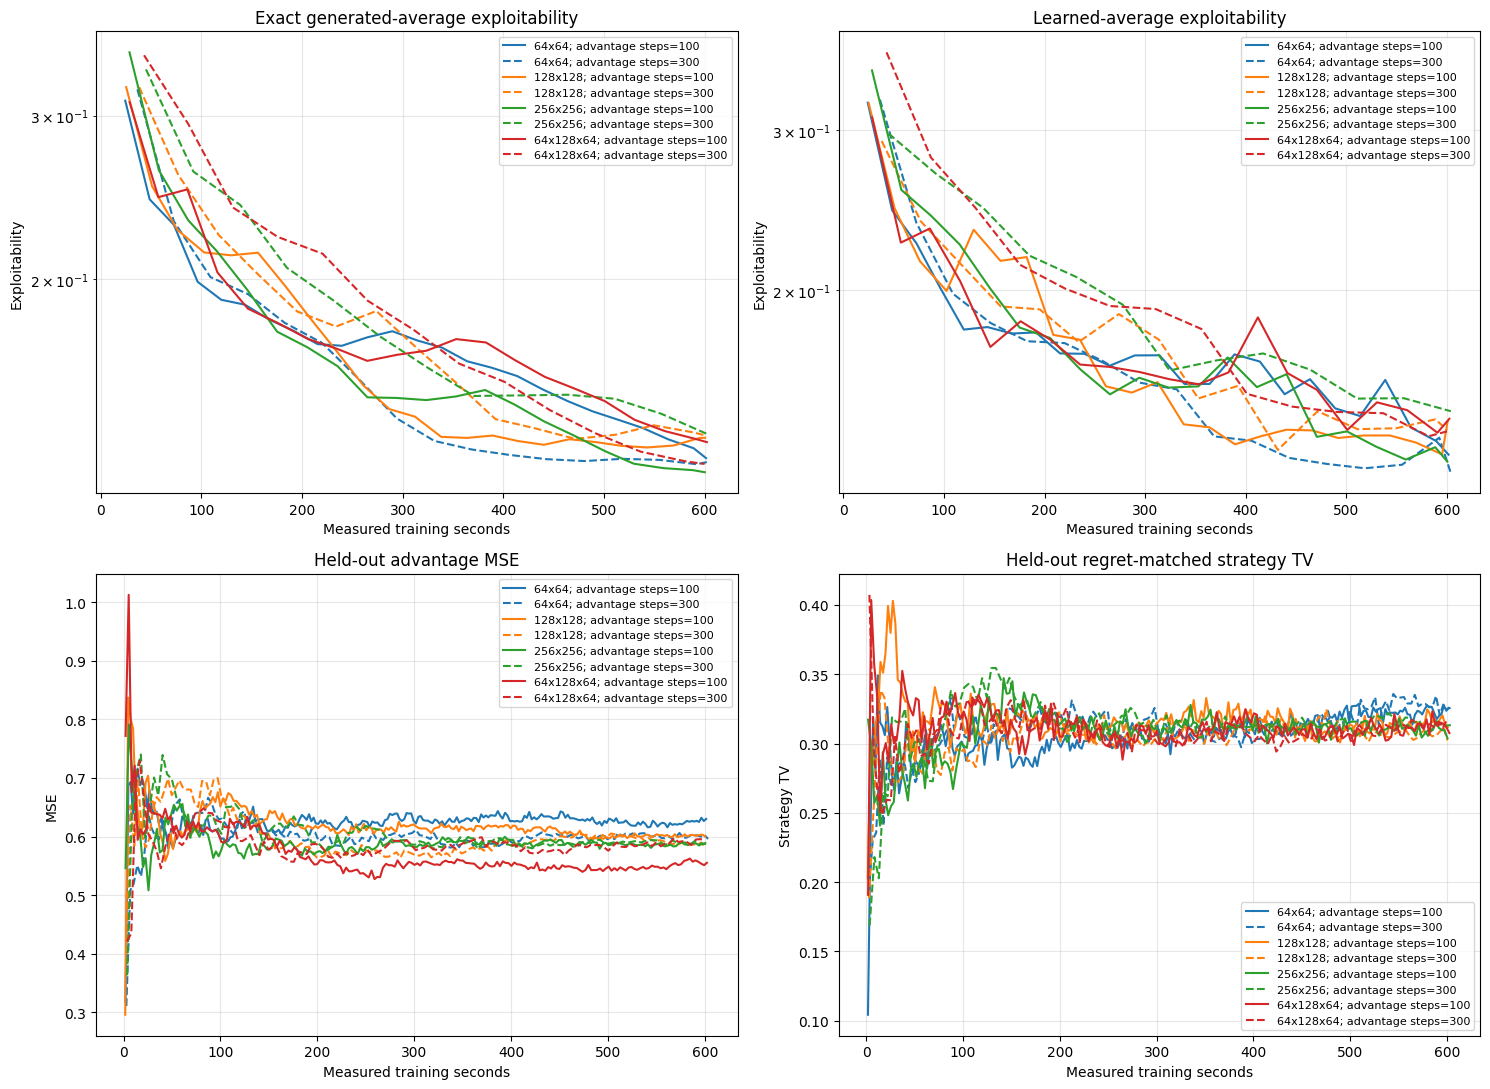

In [9]:
colors = {'64x64': 'C0', '128x128': 'C1', '256x256': 'C2', '64x128x64': 'C3'}
styles = {100: '-', 300: '--'}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for run in runs:
    seconds = evaluation_seconds(run)
    style = styles[run['advantage_steps']]
    color = colors[run['architecture']]
    label = run['label']
    axes[0, 0].plot(seconds, exploitability_values(run, 'exact_average_predicted_avg'), style, color=color, label=label)
    axes[0, 1].plot(seconds, exploitability_values(run, 'predicted_avg'), style, color=color, label=label)
    x, y = validation_series(run, 'advantage', 'mse')
    axes[1, 0].plot(x, y, style, color=color, label=label)
    x, y = validation_series(run, 'advantage', 'strategy_tv')
    axes[1, 1].plot(x, y, style, color=color, label=label)

plot_specs = [
    ('Exact generated-average exploitability', 'Exploitability', True),
    ('Learned-average exploitability', 'Exploitability', True),
    ('Held-out advantage MSE', 'MSE', False),
    ('Held-out regret-matched strategy TV', 'Strategy TV', False),
]
for ax, (title, ylabel, log_y) in zip(axes.flat, plot_specs):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();

In [10]:
summary_rows = []
for run in runs:
    training = run['logs']['training_series']
    exact = exploitability_values(run, 'exact_average_predicted_avg')
    learned = exploitability_values(run, 'predicted_avg')
    current = exploitability_values(run, 'current_predicted_avg')
    seconds = evaluation_seconds(run)
    _, validation_mse = validation_series(run, 'advantage', 'mse')
    _, validation_tv = validation_series(run, 'advantage', 'strategy_tv')
    final = training[-1]
    summary_rows.append({
        'architecture': run['architecture'],
        'advantage steps': run['advantage_steps'],
        'parameters per network': run['parameters_per_network'],
        'iterations completed': run['iterations'],
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'exact-average normalized AUC': float(np.trapezoid(exact, seconds) / (seconds[-1] - seconds[0])),
        'final learned-average exploitability': learned[-1],
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'final held-out advantage MSE': validation_mse[-1],
        'final held-out strategy TV': validation_tv[-1],
        'advantage records seen': sum(final['advantage_records_seen']),
        'mean traversal s': float(np.mean([record['timing']['traversal_s'] for record in training])),
        'mean advantage fit s': float(np.mean([record['timing']['advantage_training_s'] for record in training])),
        'mean strategy fit s': float(np.mean([record['timing']['strategy_training_s'] for record in training])),
    })

summary_df = pd.DataFrame(summary_rows).set_index(['architecture', 'advantage steps']).sort_index()
summary_df.style.format(precision=6).background_gradient(
    subset=[
        'final exact-average exploitability',
        'best exact-average exploitability',
        'exact-average normalized AUC',
    ],
    cmap='RdYlGn_r',
)

## Interaction views

These plots make it easier to see whether additional advantage steps help each architecture, and whether lower held-out MSE translates into lower exact-average exploitability.

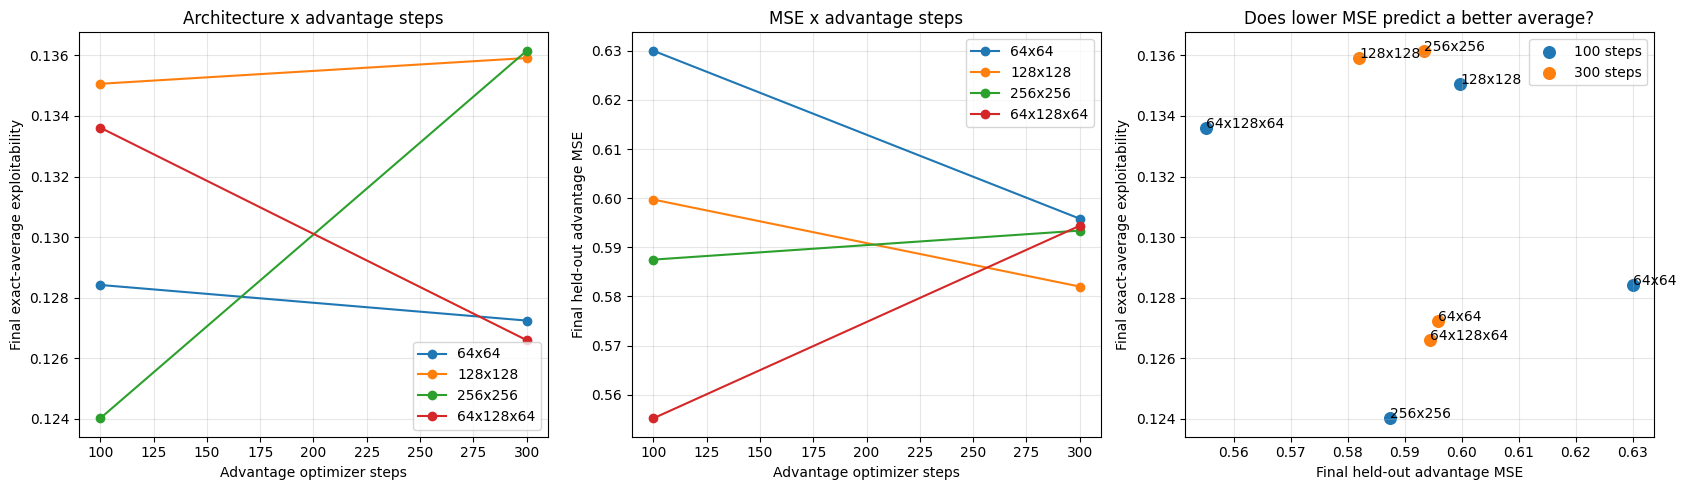

In [11]:
flat_summary = summary_df.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for architecture in architectures:
    subset = flat_summary[flat_summary['architecture'] == architecture].sort_values('advantage steps')
    axes[0].plot(subset['advantage steps'], subset['final exact-average exploitability'], marker='o', label=architecture)
    axes[1].plot(subset['advantage steps'], subset['final held-out advantage MSE'], marker='o', label=architecture)

for advantage_steps in advantage_step_options:
    subset = flat_summary[flat_summary['advantage steps'] == advantage_steps]
    axes[2].scatter(
        subset['final held-out advantage MSE'],
        subset['final exact-average exploitability'],
        label=f'{advantage_steps} steps',
        s=70,
    )
    for _, row in subset.iterrows():
        axes[2].annotate(row['architecture'], (row['final held-out advantage MSE'], row['final exact-average exploitability']))

axes[0].set(title='Architecture x advantage steps', xlabel='Advantage optimizer steps', ylabel='Final exact-average exploitability')
axes[1].set(title='MSE x advantage steps', xlabel='Advantage optimizer steps', ylabel='Final held-out advantage MSE')
axes[2].set(title='Does lower MSE predict a better average?', xlabel='Final held-out advantage MSE', ylabel='Final exact-average exploitability')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout();

## Three-seed confirmation of surviving configurations

This confirms the three practically plausible configurations from the screening experiment:

- `64x64`, 100 steps: maximum traversal/data throughput.
- `64x64`, 300 steps: more fitting of the compact network.
- `256x256`, 100 steps: greater representational capacity.

Each configuration receives the same measured training-time budget for paired seeds `7`, `17`, and `27`. Exact evaluation and exact dense averaging remain outside the measured budget.

In [12]:
confirmation_training_seconds = 10 * 60
confirmation_seeds = (7, 17, 27)
confirmation_configs = {
    '64x64; 100 steps': {'hidden_sizes': (64, 64), 'advantage_train_steps': 100},
    '64x64; 300 steps': {'hidden_sizes': (64, 64), 'advantage_train_steps': 300},
    '256x256; 100 steps': {'hidden_sizes': (256, 256), 'advantage_train_steps': 100},
}

confirmation_runs = []
for seed_value in confirmation_seeds:
    for label, config in confirmation_configs.items():
        print(f'\n=== seed={seed_value}; {label} ===')
        trainer = PositiveWeightedDeepCFRTrainer(
            spec,
            positive_beta=positive_beta,
            seed=seed_value,
            **{key: value for key, value in common_kwargs.items() if key != 'seed'},
            **config,
        )
        exact_averager = ExactDenseStrategyAverager(spec)
        _, logs, trainer = deep_cfr_timed_loop(
            spec,
            training_seconds=confirmation_training_seconds,
            trainer=trainer,
            traversals_per_player=traversals_per_player,
            eval_every=eval_every,
            exact_averager=exact_averager,
            debug=True,
        )
        confirmation_runs.append({
            'seed': seed_value,
            'label': label,
            'hidden_sizes': config['hidden_sizes'],
            'advantage_steps': config['advantage_train_steps'],
            'iterations': trainer.iteration,
            'logs': logs,
        })
        del trainer, exact_averager
        gc.collect()


=== seed=7; 64x64; 100 steps ===
[deep-cfr] iter=1 training_budget=2.04/600.00s traverse=0.46s fit=1.58s
[deep-cfr] iter=2 training_budget=5.64/600.00s traverse=2.31s fit=1.28s
[deep-cfr] iter=3 training_budget=7.97/600.00s traverse=1.12s fit=1.21s
[deep-cfr] iter=4 training_budget=10.37/600.00s traverse=1.11s fit=1.29s
[deep-cfr] iter=5 training_budget=12.71/600.00s traverse=1.14s fit=1.21s
[deep-cfr] iter=6 training_budget=14.96/600.00s traverse=1.01s fit=1.24s
[deep-cfr] iter=7 training_budget=17.31/600.00s traverse=1.13s fit=1.22s
[deep-cfr] iter=8 training_budget=19.65/600.00s traverse=1.14s fit=1.20s
[deep-cfr] iter=9 training_budget=22.06/600.00s traverse=1.10s fit=1.30s
[deep-cfr] iter=10 training_budget=24.42/600.00s traverse=1.19s fit=1.18s
[deep-cfr] iter=11 training_budget=26.77/600.00s traverse=1.13s fit=1.22s
[deep-cfr] iter=12 training_budget=29.16/600.00s traverse=1.14s fit=1.24s
[deep-cfr] iter=13 training_budget=31.54/600.00s traverse=1.15s fit=1.24s
[deep-cfr] iter=

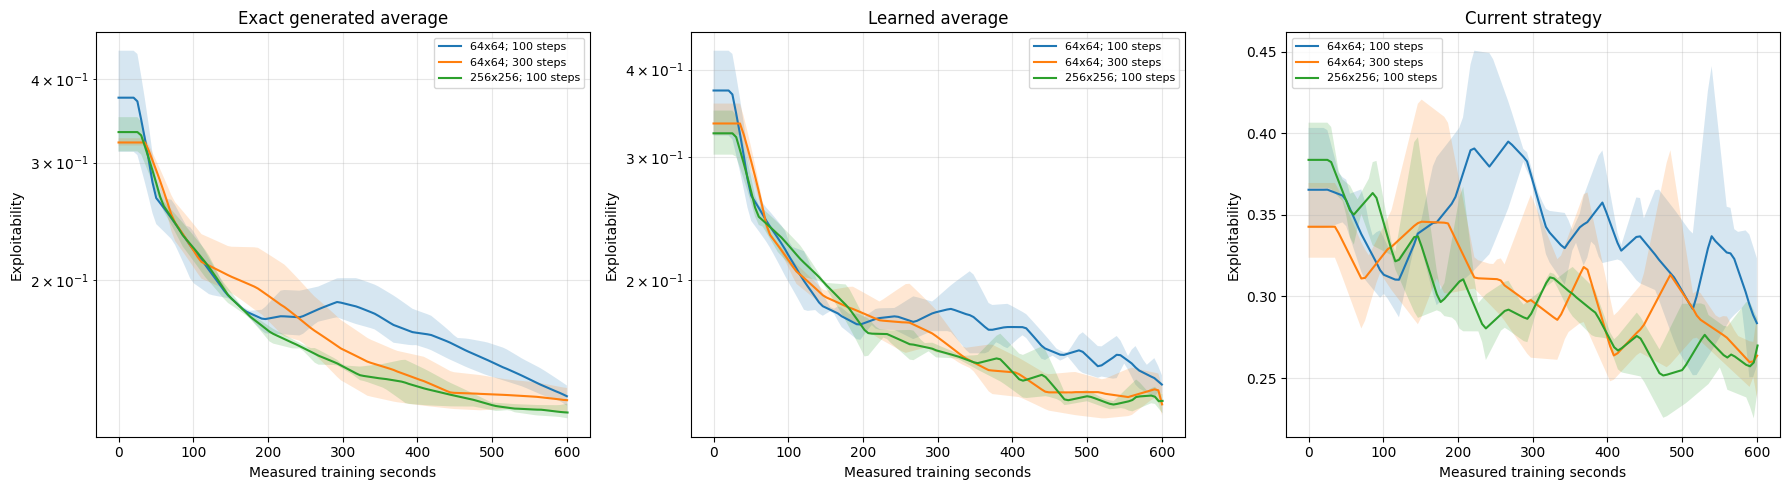

In [13]:
def interpolate_confirmation(selected_runs, key, points=120):
    stop = min(evaluation_seconds(run)[-1] for run in selected_runs)
    grid = np.linspace(0.0, stop, points)
    values = np.asarray([
        np.interp(grid, evaluation_seconds(run), exploitability_values(run, key))
        for run in selected_runs
    ])
    return grid, values


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for label in confirmation_configs:
    selected = [run for run in confirmation_runs if run['label'] == label]
    for ax, key in zip(
        axes,
        ('exact_average_predicted_avg', 'predicted_avg', 'current_predicted_avg'),
    ):
        x, values = interpolate_confirmation(selected, key)
        ax.plot(x, values.mean(axis=0), label=label)
        ax.fill_between(x, values.min(axis=0), values.max(axis=0), alpha=0.18)

for ax, title, log_y in zip(
    axes,
    ('Exact generated average', 'Learned average', 'Current strategy'),
    (True, True, False),
):
    ax.set(title=title, xlabel='Measured training seconds', ylabel='Exploitability')
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();

In [14]:
confirmation_rows = []
for run in confirmation_runs:
    training = run['logs']['training_series']
    exact = exploitability_values(run, 'exact_average_predicted_avg')
    learned = exploitability_values(run, 'predicted_avg')
    current = exploitability_values(run, 'current_predicted_avg')
    seconds = evaluation_seconds(run)
    _, validation_mse = validation_series(run, 'advantage', 'mse')
    final = training[-1]
    confirmation_rows.append({
        'seed': run['seed'],
        'configuration': run['label'],
        'iterations completed': run['iterations'],
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'exact-average normalized AUC': float(np.trapezoid(exact, seconds) / (seconds[-1] - seconds[0])),
        'final learned-average exploitability': learned[-1],
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'final held-out advantage MSE': validation_mse[-1],
        'advantage records seen': sum(final['advantage_records_seen']),
        'mean traversal s': float(np.mean([record['timing']['traversal_s'] for record in training])),
        'mean advantage fit s': float(np.mean([record['timing']['advantage_training_s'] for record in training])),
        'mean strategy fit s': float(np.mean([record['timing']['strategy_training_s'] for record in training])),
    })

confirmation_df = pd.DataFrame(confirmation_rows).set_index(['seed', 'configuration']).sort_index()
display(confirmation_df.style.format(precision=6))

confirmation_aggregate = confirmation_df.groupby(level='configuration').agg(['mean', 'std'])
confirmation_aggregate.style.format(precision=6).background_gradient(
    subset=[
        ('final exact-average exploitability', 'mean'),
        ('best exact-average exploitability', 'mean'),
        ('exact-average normalized AUC', 'mean'),
    ],
    cmap='RdYlGn_r',
)

In [15]:
paired = confirmation_df.reset_index().pivot(index='seed', columns='configuration')
reference = '64x64; 100 steps'
paired_rows = []
for competitor in ('64x64; 300 steps', '256x256; 100 steps'):
    for seed_value in confirmation_seeds:
        paired_rows.append({
            'seed': seed_value,
            'competitor minus reference': competitor,
            'final exact-average difference': (
                paired.loc[seed_value, ('final exact-average exploitability', competitor)]
                - paired.loc[seed_value, ('final exact-average exploitability', reference)]
            ),
            'exact-average AUC difference': (
                paired.loc[seed_value, ('exact-average normalized AUC', competitor)]
                - paired.loc[seed_value, ('exact-average normalized AUC', reference)]
            ),
            'held-out MSE difference': (
                paired.loc[seed_value, ('final held-out advantage MSE', competitor)]
                - paired.loc[seed_value, ('final held-out advantage MSE', reference)]
            ),
        })

paired_confirmation = pd.DataFrame(paired_rows).set_index(['competitor minus reference', 'seed'])
paired_confirmation.style.format(precision=6).background_gradient(cmap='RdYlGn_r', axis=None)